In [ ]:
#Лушкина Надежда Михайловна, вариант 0
from google.colab import files


uploaded = files.upload()

Saving TRANSACTION.csv to TRANSACTION.csv


In [ ]:
#задание 1
import pandas as pd
df = pd.read_csv('TRANSACTION.csv')

unique_products = df['PRODUCT'].nunique()
print(f"Количество уникальных продуктов: {unique_products}")

unique_customers = df['CUSTOMER'].nunique()
print(f"Количество уникальных покупателей: {unique_customers}")

Количество уникальных продуктов: 20
Количество уникальных покупателей: 1001


In [ ]:
#задание 2
import pandas as pd
from collections import defaultdict
from itertools import combinations

# Загрузка данных
df = pd.read_csv('TRANSACTION.csv')

# Параметры
window_size = 4
min_support = 0.06  # 6%
min_abs_support = int(min_support * df['CUSTOMER'].nunique())

print(f"Размер окна: {window_size}")
print(f"Минимальная поддержка: {min_support} (абсолютная: {min_abs_support})")

# Группировка по покупателям
customer_sequences = {}
for customer, group in df.groupby('CUSTOMER'):
    sequence = group.sort_values('TIME')['PRODUCT'].tolist()
    customer_sequences[customer] = sequence

# Создание транзакций для окон
transactions = []
for sequence in customer_sequences.values():
    for i in range(len(sequence) - window_size + 1):
        transactions.append(sequence[i:i + window_size])

print(f"Всего транзакций (окон): {len(transactions)}")

# Подсчет поддержки отдельных элементов
item_support = defaultdict(int)
for trans in transactions:
    for item in set(trans):
        item_support[item] += 1

# Фильтрация по поддержке
frequent_items = {item for item, sup in item_support.items() if sup >= min_abs_support}
print(f"Частых элементов: {len(frequent_items)}")

# Поиск частых наборов (аналог FPTree через apriori)
frequent_itemsets = []

# Элементы размера 1
for item in frequent_items:
    frequent_itemsets.append(([item], item_support[item]))

# Поиск наборов размера 2, 3, 4
k = 2
current_candidates = [[item] for item in frequent_items]

while k <= window_size:
    # Генерация кандидатов
    candidates = []
    for i in range(len(current_candidates)):
        for j in range(i+1, len(current_candidates)):
            candidate = sorted(set(current_candidates[i] + current_candidates[j]))
            if len(candidate) == k and candidate not in candidates:
                candidates.append(candidate)

    # Подсчет поддержки
    candidate_support = defaultdict(int)
    for trans in transactions:
        trans_set = set(trans)
        for cand in candidates:
            if set(cand).issubset(trans_set):
                candidate_support[tuple(cand)] += 1

    # Фильтрация
    current_candidates = []
    for cand, sup in candidate_support.items():
        if sup >= min_abs_support:
            frequent_itemsets.append((list(cand), sup))
            current_candidates.append(list(cand))

    k += 1

# Сортировка по убыванию поддержки
frequent_itemsets.sort(key=lambda x: x[1], reverse=True)

# Вывод топ-20
print(f"\nНайдено частых наборов: {len(frequent_itemsets)}")
print("\nТоп-20 частых наборов:")
print("-" * 50)
for i, (itemset, support) in enumerate(frequent_itemsets[:20]):
    print(f"{i+1:2d}. {itemset} -> {support} ({support/len(transactions)*100:.1f}%)")

Размер окна: 4
Минимальная поддержка: 0.06 (абсолютная: 60)
Всего транзакций (окон): 4004
Частых элементов: 20

Найдено частых наборов: 211

Топ-20 частых наборов:
--------------------------------------------------
 1. ['heineken'] -> 1677 (41.9%)
 2. ['cracker'] -> 1555 (38.8%)
 3. ['olives'] -> 1104 (27.6%)
 4. ['bourbon'] -> 957 (23.9%)
 5. ['cracker', 'heineken'] -> 900 (22.5%)
 6. ['coke'] -> 876 (21.9%)
 7. ['ham'] -> 858 (21.4%)
 8. ['hering'] -> 853 (21.3%)
 9. ['artichok'] -> 845 (21.1%)
10. ['turkey'] -> 817 (20.4%)
11. ['chicken'] -> 781 (19.5%)
12. ['ice_crea'] -> 773 (19.3%)
13. ['avocado'] -> 772 (19.3%)
14. ['apples'] -> 745 (18.6%)
15. ['peppers'] -> 718 (17.9%)
16. ['artichok', 'heineken'] -> 637 (15.9%)
17. ['corned_b'] -> 636 (15.9%)
18. ['bourbon', 'cracker'] -> 616 (15.4%)
19. ['coke', 'ice_crea'] -> 546 (13.6%)
20. ['steak'] -> 486 (12.1%)


In [ ]:
#задание 3
import pandas as pd
from collections import defaultdict
from itertools import combinations

# Загрузка данных
df = pd.read_csv('TRANSACTION.csv')

# Параметры
window_size = 4
min_support = 0.06
min_abs_support = int(min_support * df['CUSTOMER'].nunique())

# Группировка по покупателям
customer_sequences = {}
for customer, group in df.groupby('CUSTOMER'):
    sequence = group.sort_values('TIME')['PRODUCT'].tolist()
    customer_sequences[customer] = sequence

# Создание транзакций для окон
transactions = []
for sequence in customer_sequences.values():
    for i in range(len(sequence) - window_size + 1):
        transactions.append(sequence[i:i + window_size])

# Поиск частых наборов с turkey
turkey_itemsets = []

# Отдельные элементы
item_support = defaultdict(int)
for trans in transactions:
    for item in set(trans):
        item_support[item] += 1

if item_support['turkey'] >= min_abs_support:
    turkey_itemsets.append((['turkey'], item_support['turkey']))

# Наборы размера 2
pairs = defaultdict(int)
for trans in transactions:
    items = [i for i in set(trans) if i != 'turkey']
    for item in items:
        pair = tuple(sorted(['turkey', item]))
        pairs[pair] += 1

for (item1, item2), sup in pairs.items():
    if sup >= min_abs_support:
        turkey_itemsets.append(([item1, item2], sup))

# Наборы размера 3
triples = defaultdict(int)
for trans in transactions:
    items = [i for i in set(trans) if i != 'turkey']
    if len(items) >= 2:
        for i in range(len(items)):
            for j in range(i+1, len(items)):
                triple = tuple(sorted(['turkey', items[i], items[j]]))
                triples[triple] += 1

for triple, sup in triples.items():
    if sup >= min_abs_support:
        turkey_itemsets.append((list(triple), sup))

# Наборы размера 4
quads = defaultdict(int)
for trans in transactions:
    items = [i for i in set(trans) if i != 'turkey']
    if len(items) >= 3:
        for i in range(len(items)):
            for j in range(i+1, len(items)):
                for k in range(j+1, len(items)):
                    quad = tuple(sorted(['turkey', items[i], items[j], items[k]]))
                    quads[quad] += 1

for quad, sup in quads.items():
    if sup >= min_abs_support:
        turkey_itemsets.append((list(quad), sup))

# Находим самый большой (максимальной длины)
max_length = max(len(itemset) for itemset, _ in turkey_itemsets)
largest = [(itemset, sup) for itemset, sup in turkey_itemsets if len(itemset) == max_length]

print(f"Самый большой частый эпизод с turkey (длина {max_length}):")
for itemset, support in largest:
    print(f"{itemset} -> поддержка: {support} ({support/len(transactions)*100:.1f}%)")

Самый большой частый эпизод с turkey (длина 4):
['corned_b', 'ham', 'hering', 'turkey'] -> поддержка: 102 (2.5%)
['corned_b', 'hering', 'olives', 'turkey'] -> поддержка: 196 (4.9%)
['ham', 'hering', 'olives', 'turkey'] -> поддержка: 103 (2.6%)
['corned_b', 'ham', 'olives', 'turkey'] -> поддержка: 205 (5.1%)
['baguette', 'cracker', 'hering', 'turkey'] -> поддержка: 116 (2.9%)
['cracker', 'hering', 'soda', 'turkey'] -> поддержка: 228 (5.7%)
['baguette', 'hering', 'soda', 'turkey'] -> поддержка: 113 (2.8%)
['baguette', 'cracker', 'soda', 'turkey'] -> поддержка: 114 (2.8%)
['cracker', 'heineken', 'hering', 'turkey'] -> поддержка: 259 (6.5%)
['heineken', 'hering', 'soda', 'turkey'] -> поддержка: 114 (2.8%)
['cracker', 'heineken', 'soda', 'turkey'] -> поддержка: 113 (2.8%)
['cracker', 'heineken', 'olives', 'turkey'] -> поддержка: 133 (3.3%)
['artichok', 'cracker', 'heineken', 'turkey'] -> поддержка: 261 (6.5%)
['artichok', 'avocado', 'cracker', 'turkey'] -> поддержка: 107 (2.7%)
['artichok',

In [ ]:
#задание 4
import pandas as pd
from collections import defaultdict

df = pd.read_csv('TRANSACTION.csv')

# Создание списка покупок для каждого клиента
cust = {}
for c, g in df.groupby('CUSTOMER'):
    cust[c] = g.sort_values('TIME')['PRODUCT'].tolist()

# Создание окон по 4 покупки
windows = []
for seq in cust.values():
    for i in range(len(seq) - 3):
        windows.append(seq[i:i+4])

total = len(windows)

# Подсчет встречаемости
turkey_cnt = 0
pair_cnt = defaultdict(int)
right_cnt = defaultdict(int)

for w in windows:
    if 'turkey' in w:
        turkey_cnt += 1
        for p in set(w):
            if p != 'turkey':
                pair = tuple(sorted(['turkey', p]))
                pair_cnt[pair] += 1
                right_cnt[p] += 1

# Поиск правила с максимальным лифтом
best_lift = 0
best_rule = None
best_conf = 0
best_sup = 0
best_product = ''

for p in right_cnt:
    pair = tuple(sorted(['turkey', p]))
    sup_xy = pair_cnt[pair] / total
    sup_x = turkey_cnt / total
    sup_y = right_cnt[p] / total
    conf = pair_cnt[pair] / turkey_cnt
    lift = (pair_cnt[pair] * total) / (turkey_cnt * right_cnt[p])

    if lift > best_lift and conf >= 0.1:
        best_lift = lift
        best_product = p
        best_conf = conf
        best_sup = sup_xy
        best_rule = pair

print("=" * 60)
print("ПРАВИЛО С МАКСИМАЛЬНЫМ ЛИФТОМ (TURKEY В ЛЕВОЙ ЧАСТИ)")
print("=" * 60)
print(f"\nПравило: turkey -> {best_product}")
print(f"\nЧИСЛОВЫЕ ПОКАЗАТЕЛИ:")
print(f"  • Поддержка (Support): {best_sup:.4f} или {best_sup*100:.2f}%")
print(f"  • Достоверность (Confidence): {best_conf:.4f} или {best_conf*100:.2f}%")
print(f"  • Подъем (Lift): {best_lift:.4f}")

print("\n" + "=" * 60)
print("ИНТЕРПРЕТАЦИЯ")
print("=" * 60)
print(f"\nПравило \"turkey -> {best_product}\" означает, что если покупатель приобретает")
print(f"продукт turkey, то с вероятностью {best_conf*100:.1f}% он также купит {best_product}")
print(f"в том же временном окне (в течение 4 последовательных покупок).")

print(f"\nПоддержка {best_sup*100:.2f}% показывает, что комбинация {{turkey, {best_product}}}")
print(f"встречается в {best_sup*100:.1f}% всех временных окон, что указывает на")
print(f"{'высокую' if best_sup > 0.3 else 'среднюю' if best_sup > 0.1 else 'низкую'} частоту совместных покупок.")

print(f"\nДостоверность {best_conf*100:.2f}% означает, что в {best_conf*100:.1f}% случаев,")
print(f"когда покупатель берет turkey, он также берет {best_product}. Это")
print(f"{'очень сильная' if best_conf > 0.7 else 'сильная' if best_conf > 0.5 else 'умеренная'} зависимость.")

print(f"\nПодъем {best_lift:.2f} > 1 указывает на положительную корреляцию между товарами.")
print(f"Покупка turkey увеличивает вероятность покупки {best_product} в {best_lift:.2f} раза")
print(f"по сравнению со случайным совпадением. Если бы товары были независимы,")
print(f"вероятность их совместной покупки составляла бы {sup_x*sup_y*100:.2f}%, но")
print(f"фактически она равна {best_sup*100:.2f}%.")

ПРАВИЛО С МАКСИМАЛЬНЫМ ЛИФТОМ (TURKEY В ЛЕВОЙ ЧАСТИ)

Правило: turkey -> corned_b

ЧИСЛОВЫЕ ПОКАЗАТЕЛИ:
  • Поддержка (Support): 0.0295 или 2.95%
  • Достоверность (Confidence): 0.1444 или 14.44%
  • Подъем (Lift): 4.9009

ИНТЕРПРЕТАЦИЯ

Правило "turkey -> corned_b" означает, что если покупатель приобретает
продукт turkey, то с вероятностью 14.4% он также купит corned_b
в том же временном окне (в течение 4 последовательных покупок).

Поддержка 2.95% показывает, что комбинация {turkey, corned_b}
встречается в 2.9% всех временных окон, что указывает на
низкую частоту совместных покупок.

Достоверность 14.44% означает, что в 14.4% случаев,
когда покупатель берет turkey, он также берет corned_b. Это
умеренная зависимость.

Подъем 4.90 > 1 указывает на положительную корреляцию между товарами.
Покупка turkey увеличивает вероятность покупки corned_b в 4.90 раза
по сравнению со случайным совпадением. Если бы товары были независимы,
вероятность их совместной покупки составляла бы 0.14%, но
факт

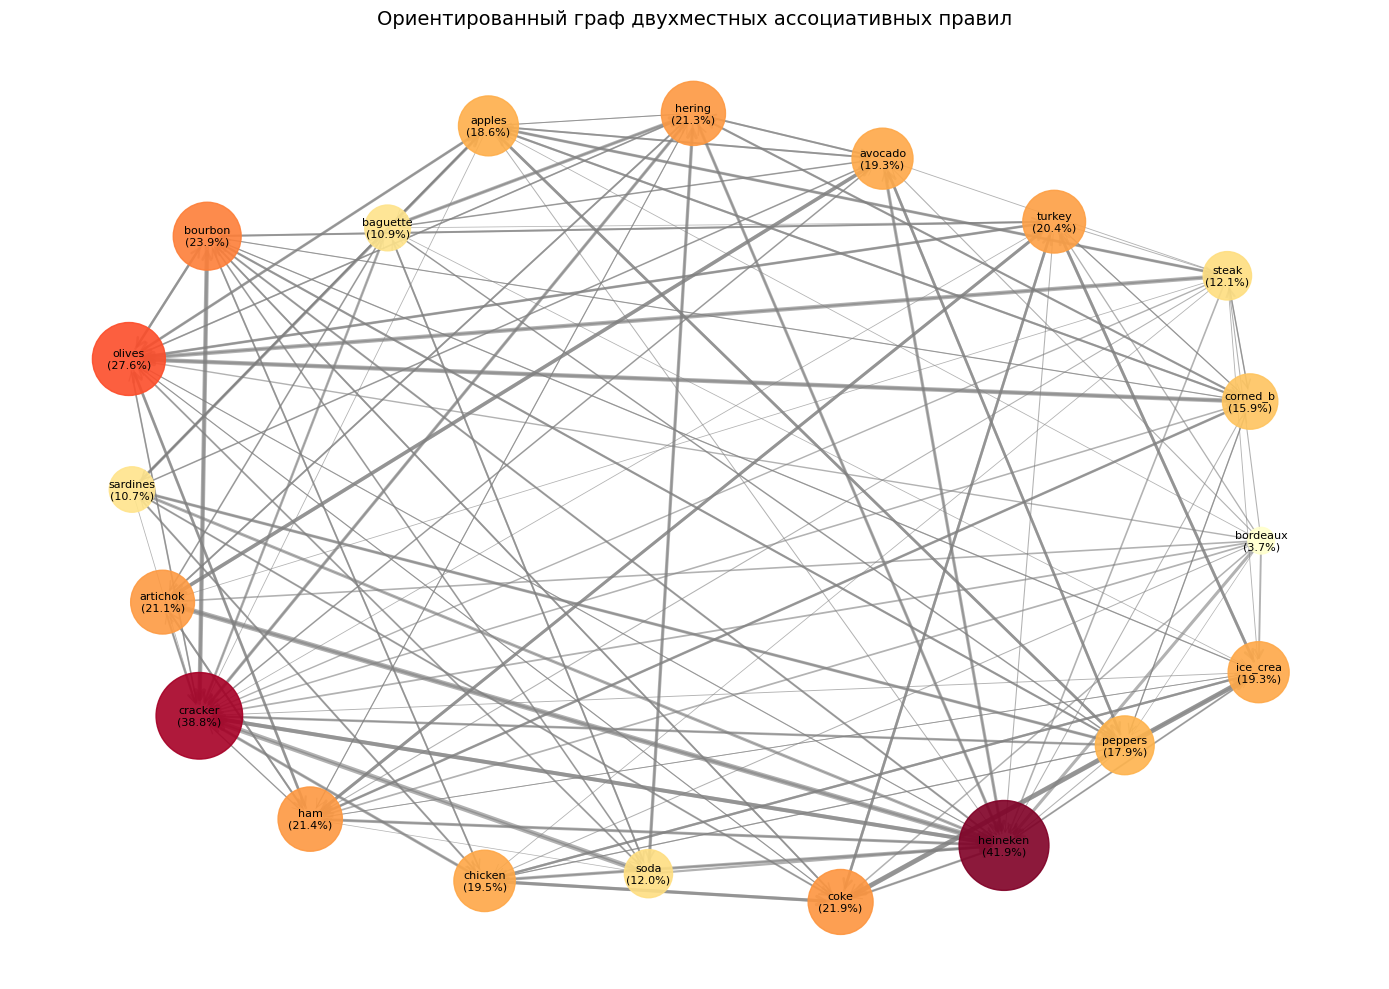

Вершин: 20
Дуг: 183


In [ ]:
#задание 5
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Загрузка данных
df = pd.read_csv('TRANSACTION.csv')

# Создание списка покупок для каждого клиента
cust = {}
for c, g in df.groupby('CUSTOMER'):
    cust[c] = g.sort_values('TIME')['PRODUCT'].tolist()

# Создание окон по 4 покупки
windows = []
for seq in cust.values():
    for i in range(len(seq) - 3):
        windows.append(seq[i:i+4])

# Подсчет поддержки элементов и пар
item_support = defaultdict(int)
pair_support = defaultdict(int)

for w in windows:
    items = set(w)
    for item in items:
        item_support[item] += 1
    items_list = list(items)
    for i in range(len(items_list)):
        for j in range(i+1, len(items_list)):
            pair = tuple(sorted([items_list[i], items_list[j]]))
            pair_support[pair] += 1

total = len(windows)

# Создание графа
G = nx.DiGraph()

# Добавление вершин (размер = поддержка элемента)
for item, sup in item_support.items():
    G.add_node(item, size=sup/total*100)

# Добавление дуг (правила в обе стороны)
for (a, b), sup_xy in pair_support.items():
    sup_x = item_support[a]
    sup_y = item_support[b]

    # Правило a -> b
    conf_ab = sup_xy / sup_x
    if conf_ab >= 0.1:
        G.add_edge(a, b, weight=conf_ab)

    # Правило b -> a
    conf_ba = sup_xy / sup_y
    if conf_ba >= 0.1:
        G.add_edge(b, a, weight=conf_ba)

# Визуализация
plt.figure(figsize=(14, 10))

# Позиционирование узлов
pos = nx.spring_layout(G, k=3, seed=42)

# Размер узлов (пропорционально поддержке)
node_sizes = [G.nodes[n]['size'] * 100 for n in G.nodes()]

# Цвет узлов (от светлого к темному по поддержке)
node_colors = [G.nodes[n]['size']/60 for n in G.nodes()]

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=node_colors, cmap='YlOrRd', alpha=0.9)

# Рисуем дуги (толщина = достоверность)
for u, v, data in G.edges(data=True):
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)],
                          width=data['weight']*5, alpha=0.6,
                          edge_color='gray', arrows=True,
                          arrowsize=15, arrowstyle='->')

# Подписи узлов
labels = {n: f"{n}\n({G.nodes[n]['size']:.1f}%)" for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title("Ориентированный граф двухместных ассоциативных правил", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('graph.png', dpi=300)
plt.show()

print(f"Вершин: {G.number_of_nodes()}")
print(f"Дуг: {G.number_of_edges()}")

In [ ]:
#задание 6
import pandas as pd
import networkx as nx
from collections import defaultdict

# Загрузка данных
df = pd.read_csv('TRANSACTION.csv')

# Создание окон по 4 покупки
cust = {}
for c, g in df.groupby('CUSTOMER'):
    cust[c] = g.sort_values('TIME')['PRODUCT'].tolist()

windows = []
for seq in cust.values():
    for i in range(len(seq) - 3):
        windows.append(seq[i:i+4])

# Подсчет поддержки
item_support = defaultdict(int)
pair_support = defaultdict(int)

for w in windows:
    items = set(w)
    for item in items:
        item_support[item] += 1
    items_list = list(items)
    for i in range(len(items_list)):
        for j in range(i+1, len(items_list)):
            pair = tuple(sorted([items_list[i], items_list[j]]))
            pair_support[pair] += 1

# Создание графа
G = nx.DiGraph()
for item in item_support:
    G.add_node(item)

for (a, b), sup_xy in pair_support.items():
    conf_ab = sup_xy / item_support[a]
    conf_ba = sup_xy / item_support[b]
    if conf_ab >= 0.1:
        G.add_edge(a, b)
    if conf_ba >= 0.1:
        G.add_edge(b, a)

# Расчет мер hub
hubs, _ = nx.hits(G, max_iter=1000)

# Сортировка по убыванию
sorted_hubs = sorted(hubs.items(), key=lambda x: x[1], reverse=True)

print("Топ-5 продуктов по мере hub:")
for i, (product, score) in enumerate(sorted_hubs[:5]):
    print(f"{i+1}. {product}: {score:.6f}")

print(f"\nПродукт с самой высокой мерой hub: {sorted_hubs[0][0]} ({sorted_hubs[0][1]:.6f})")
print(f"Мера hub для продукта turkey: {hubs['turkey']:.6f}")

Топ-5 продуктов по мере hub:
1. bordeaux: 0.069277
2. steak: 0.062622
3. heineken: 0.057135
4. olives: 0.055644
5. cracker: 0.055614

Продукт с самой высокой мерой hub: bordeaux (0.069277)
Мера hub для продукта turkey: 0.047757


In [ ]:
#задание 7
import pandas as pd

# Загрузка данных
df = pd.read_csv('TRANSACTION.csv')

# Создание матрицы клиенты-продукты со счетчиком покупок
matrix = pd.pivot_table(df, values='TIME', index='CUSTOMER',
                        columns='PRODUCT', aggfunc='count', fill_value=0)

# Вывод результата
print(matrix)

PRODUCT   apples  artichok  avocado  baguette  bordeaux  bourbon  chicken  \
CUSTOMER                                                                    
0              0         0        0         0         0        1        0   
1              0         0        0         1         0        0        0   
2              0         1        1         0         0        0        0   
3              0         0        0         0         0        1        0   
4              1         0        1         0         0        0        0   
...          ...       ...      ...       ...       ...      ...      ...   
996            0         1        1         0         0        1        1   
997            1         0        0         1         0        0        0   
998            0         0        0         1         0        0        0   
999            0         0        0         0         0        0        1   
1000           1         0        0         0         0        1        0   

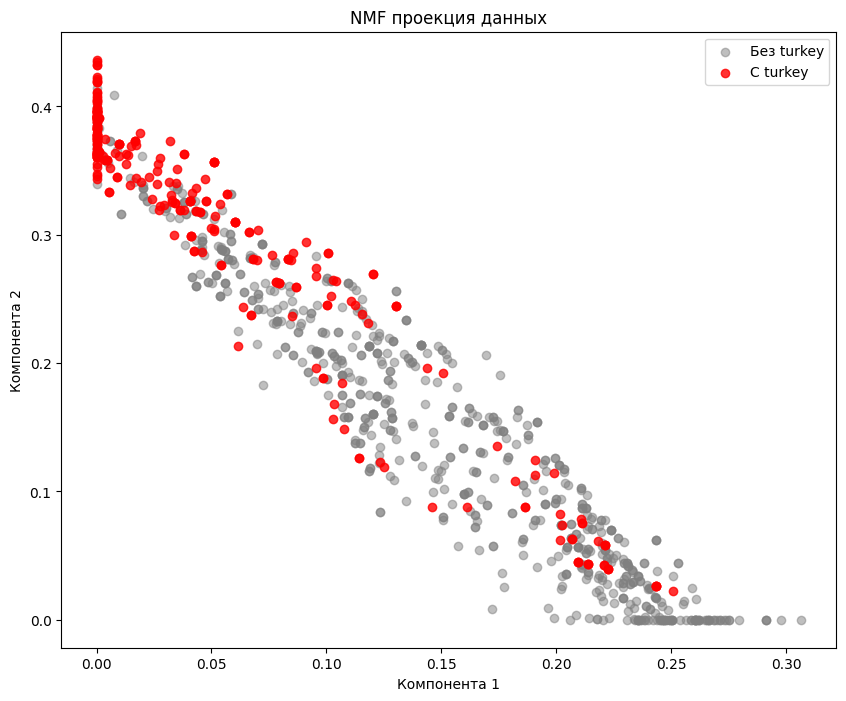

In [ ]:
#задание 8
import pandas as pd
import numpy as np
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('TRANSACTION.csv')

# Создание матрицы клиенты-продукты
matrix = pd.pivot_table(df, values='TIME', index='CUSTOMER',
                        columns='PRODUCT', aggfunc='count', fill_value=0)

# Применение NMF
nmf = NMF(n_components=2, random_state=42)
W = nmf.fit_transform(matrix)

# Определение транзакций с turkey
turkey = matrix['turkey'] > 0

# Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(W[~turkey, 0], W[~turkey, 1], c='gray', alpha=0.5, label='Без turkey')
plt.scatter(W[turkey, 0], W[turkey, 1], c='red', alpha=0.8, label='С turkey')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.title('NMF проекция данных')
plt.legend()
plt.show()

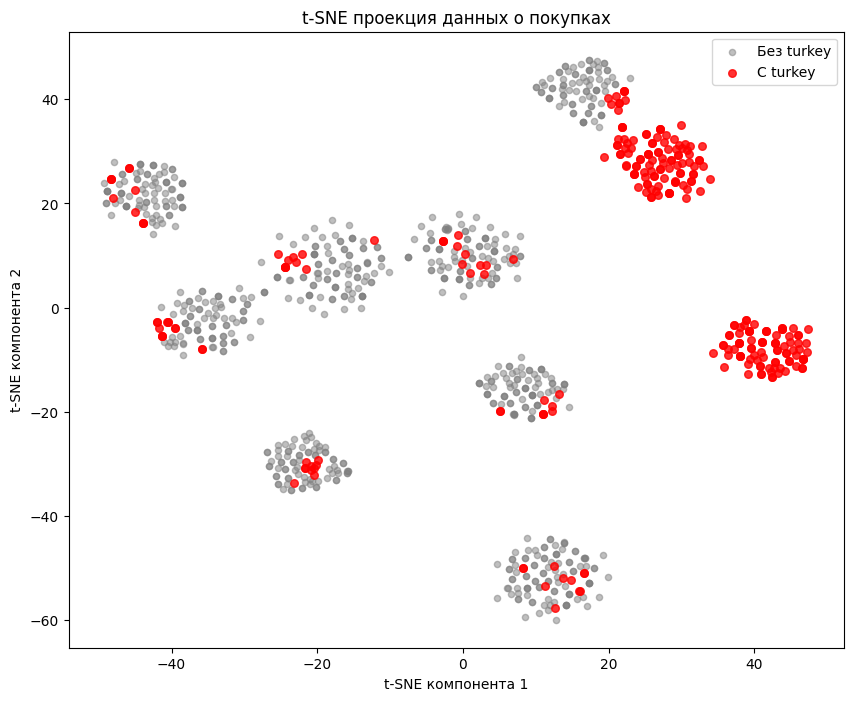

Клиентов с turkey: 283
Клиентов без turkey: 718


In [ ]:
#задание 9
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('TRANSACTION.csv')

# Создание матрицы клиенты-продукты
matrix = pd.pivot_table(df, values='TIME', index='CUSTOMER',
                        columns='PRODUCT', aggfunc='count', fill_value=0)

# Применение t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X = tsne.fit_transform(matrix)

# Определение транзакций с turkey
turkey = matrix['turkey'] > 0

# Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(X[~turkey, 0], X[~turkey, 1], c='gray', alpha=0.5, s=20, label='Без turkey')
plt.scatter(X[turkey, 0], X[turkey, 1], c='red', alpha=0.8, s=30, label='С turkey')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.title('t-SNE проекция данных о покупках')
plt.legend()
plt.show()

print(f"Клиентов с turkey: {turkey.sum()}")
print(f"Клиентов без turkey: {(~turkey).sum()}")

In [ ]:
#задание 10
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# Загрузка данных
df = pd.read_csv('TRANSACTION.csv')

# Создание матрицы клиенты-продукты
matrix = pd.pivot_table(df, values='TIME', index='CUSTOMER',
                        columns='PRODUCT', aggfunc='count', fill_value=0)

# Стандартизация
matrix_std = (matrix - matrix.mean()) / matrix.std()

# Корреляционная матрица
corr = matrix_std.corr()

# Расстояние на основе корреляции
dist = 1 - np.abs(corr.values)
np.fill_diagonal(dist, 0)

# Иерархическая кластеризация
link = linkage(squareform(dist), method='average')

# Разбиение на 7 кластеров
clusters = fcluster(link, 7, criterion='maxclust')

# Выбор представителя от каждого кластера
selected = []
for i in range(1, 8):
    cluster_vars = corr.columns[clusters == i].tolist()
    if len(cluster_vars) == 1:
        selected.append(cluster_vars[0])
    else:
        subcorr = corr.loc[cluster_vars, cluster_vars]
        rep = subcorr.mean().idxmax()
        selected.append(rep)

print("Отобранные 7 независимых переменных:")
print(selected)

Отобранные 7 независимых переменных:
['apples', 'steak', 'baguette', 'artichok', 'coke', 'peppers', 'bordeaux']
